In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Data Preparation

In [2]:
# โหลด metadata
meta = pd.read_csv('HAM10000_metadata.csv')
meta.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [3]:
# ตรวจสอบขนาดข้อมูล
meta.shape

(10015, 7)

In [4]:
# ตรวจสอบประเภทของแต่ละ feature
meta.dtypes

lesion_id        object
image_id         object
dx               object
dx_type          object
age             float64
sex              object
localization     object
dtype: object

In [5]:
# ตรวจสอบ missing value
meta.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [6]:
# เติมค่า Missing ใน age ด้วยค่ามัธยฐาน (median)
meta["age"] = meta["age"].fillna(meta["age"].median()).astype(int)

In [7]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder
dx_le = LabelEncoder()
meta["label_dx"] = dx_le.fit_transform(meta["dx"])
sex_le = LabelEncoder()
meta["sex_enc"] = sex_le.fit_transform(meta["sex"])
loc_le = LabelEncoder()
meta["loc_enc"] = loc_le.fit_transform(meta["localization"])

In [8]:
# Scale Age
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
meta["age_scaled"] = scaler.fit_transform(meta[["age"]])

meta.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,label_dx,sex_enc,loc_enc,age_scaled
0,HAM_0000118,ISIC_0027419,bkl,histo,80,male,scalp,2,1,11,1.663522
1,HAM_0000118,ISIC_0025030,bkl,histo,80,male,scalp,2,1,11,1.663522
2,HAM_0002730,ISIC_0026769,bkl,histo,80,male,scalp,2,1,11,1.663522
3,HAM_0002730,ISIC_0025661,bkl,histo,80,male,scalp,2,1,11,1.663522
4,HAM_0001466,ISIC_0031633,bkl,histo,75,male,ear,2,1,4,1.368014


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21456\4097366535.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


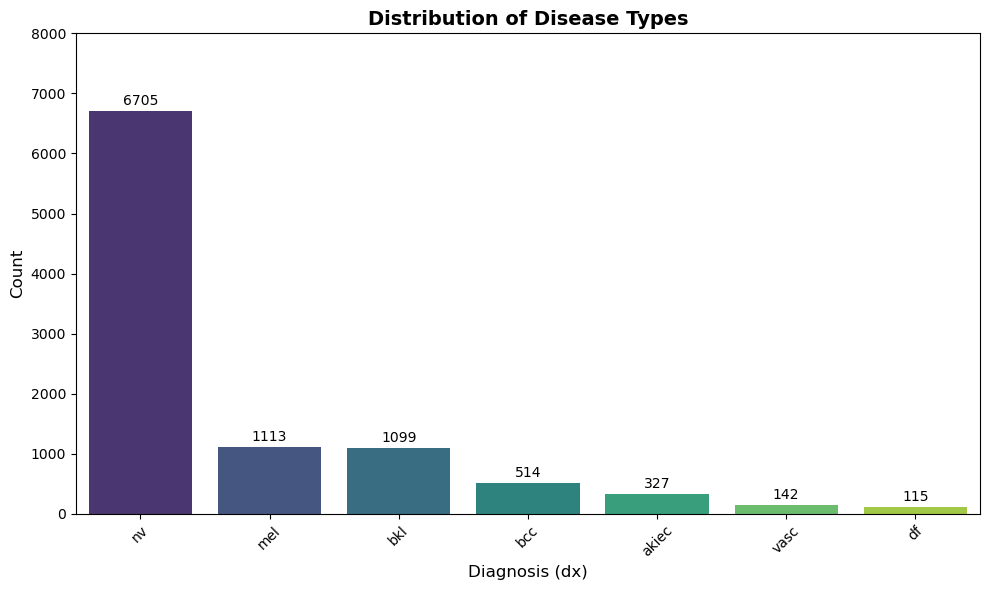

In [20]:
# ตรวจสอบการกระจายของคลาส
counts = meta['dx'].value_counts()

plt.figure(figsize=(10,6))
ax = sns.countplot(
    data=meta,
    x='dx',
    order=counts.index,
    palette='viridis'  # 🔹 เปลี่ยนสีได้ เช่น "Set2", "coolwarm", "mako", "viridis"
)

# ใส่จำนวนบนแท่ง
for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count}',
                (p.get_x() + p.get_width() / 2., p.get_height() + 50),
                ha='center', va='bottom', fontsize=10, color='black')

plt.ylim(0, 8000)
plt.xticks(rotation=45)
plt.xlabel("Diagnosis (dx)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.title("Distribution of Disease Types", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

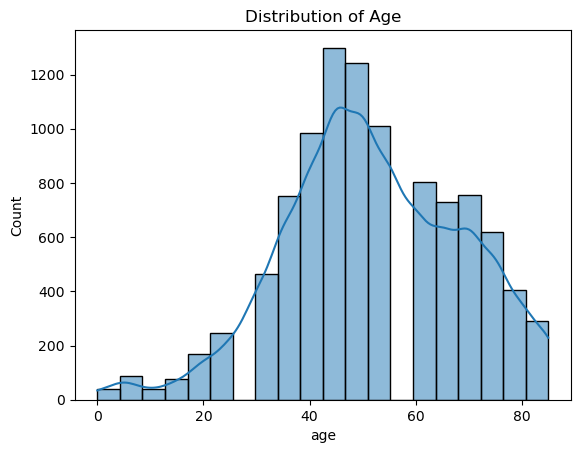

In [10]:
# การกระจายของอายุ
sns.histplot(meta['age'].dropna(), bins=20, kde=True)
plt.title('Distribution of Age')
plt.show()

In [11]:
import os
import numpy as np
from tqdm import tqdm
import cv2

# กำหนดโฟลเดอร์ภาพ
im_part1 = "HAM10000_images_part_1"
im_part2 = "HAM10000_images_part_2"

def extract_color_histogram(image_path, bins=(8, 8, 8)):
    img = cv2.imread(image_path)
    if img is None:
        return np.zeros(bins[0]*bins[1]*bins[2])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    hist = cv2.calcHist([img], [0, 1, 2], None, bins, [0,256,0,256,0,256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

# สร้าง feature vectors จาก meta["image_id"]
img_features = []

for img_id in tqdm(meta["image_id"], desc="Extracting image features"):
    # ตรวจสอบว่าไฟล์อยู่ในโฟลเดอร์ไหน
    if os.path.exists(os.path.join(im_part1, f"{img_id}.jpg")):
        path = os.path.join(im_part1, f"{img_id}.jpg")
    elif os.path.exists(os.path.join(im_part2, f"{img_id}.jpg")):
        path = os.path.join(im_part2, f"{img_id}.jpg")
    else:
        path = None
    
    hist_vector = extract_color_histogram(path) if path else np.zeros(8*8*8)
    img_features.append(hist_vector)

img_features = np.array(img_features)
print("ขนาดของ image features:", img_features.shape)


Extracting image features: 100%|█████████████████████████████████████████████████| 10015/10015 [05:07<00:00, 32.54it/s]

ขนาดของ image features: (10015, 512)


In [12]:
# รวม Features จาก Metadata + รูปภาพ

meta_features = meta[["age_scaled", "sex_enc", "loc_enc"]].values

# รวมกันเป็น feature vector เดียว
X = np.hstack([meta_features, img_features])
y = meta["label_dx"].values

print("Shape ของ Feature vector:", X.shape)
print("Shape ของ Target:", y.shape)

Shape ของ Feature vector: (10015, 515)
Shape ของ Target: (10015,)


# Train/Val/Test split (70/15/15)

In [13]:
from sklearn.model_selection import train_test_split

# แยก train 70% vs temp 30%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size = 0.30,
    random_state = 42,
    stratify = y
)

# แยก temp 30% -> val 15% , test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size = 0.50,
    random_state = 42,
    stratify = y_temp
)

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

Shapes:
X_train: (7010, 515) y_train: (7010,)
X_val: (1502, 515) y_val: (1502,)
X_test: (1503, 515) y_test: (1503,)


In [14]:
# ฟังก์ชันช่วยเช็กสัดส่วนแต่ละคลาส
import collections
def dist(lbl):
    c = collections.Counter(lbl)
    n = len(lbl)
    return {k: f"{c[k]} ({c[k]/n:.2%})" for k in sorted(c)}

print("\nClass distribution (original):")
print("  Train:", dist(y_train))
print("  Val  :", dist(y_val))
print("  Test :", dist(y_test))


Class distribution (original):
  Train: {0: '229 (3.27%)', 1: '360 (5.14%)', 2: '769 (10.97%)', 3: '81 (1.16%)', 4: '779 (11.11%)', 5: '4693 (66.95%)', 6: '99 (1.41%)'}
  Val  : {0: '49 (3.26%)', 1: '77 (5.13%)', 2: '165 (10.99%)', 3: '17 (1.13%)', 4: '167 (11.12%)', 5: '1006 (66.98%)', 6: '21 (1.40%)'}
  Test : {0: '49 (3.26%)', 1: '77 (5.12%)', 2: '165 (10.98%)', 3: '17 (1.13%)', 4: '167 (11.11%)', 5: '1006 (66.93%)', 6: '22 (1.46%)'}


In [15]:
from imblearn.over_sampling import SMOTE

# สร้าง SMOTE object
smote = SMOTE(random_state=42)

# ทำ oversample เฉพาะ train data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# เช็คจำนวนตัวอย่างแต่ละคลาสหลังทำ SMOTE
from collections import Counter
print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_res))

C:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\Lenovo\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

Before SMOTE: Counter({5: 4693, 4: 779, 2: 769, 1: 360, 0: 229, 6: 99, 3: 81})
After SMOTE: Counter({5: 4693, 4: 4693, 3: 4693, 2: 4693, 0: 4693, 6: 4693, 1: 4693})


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21456\1207175827.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_after, x="dx", y="Count", palette="viridis")


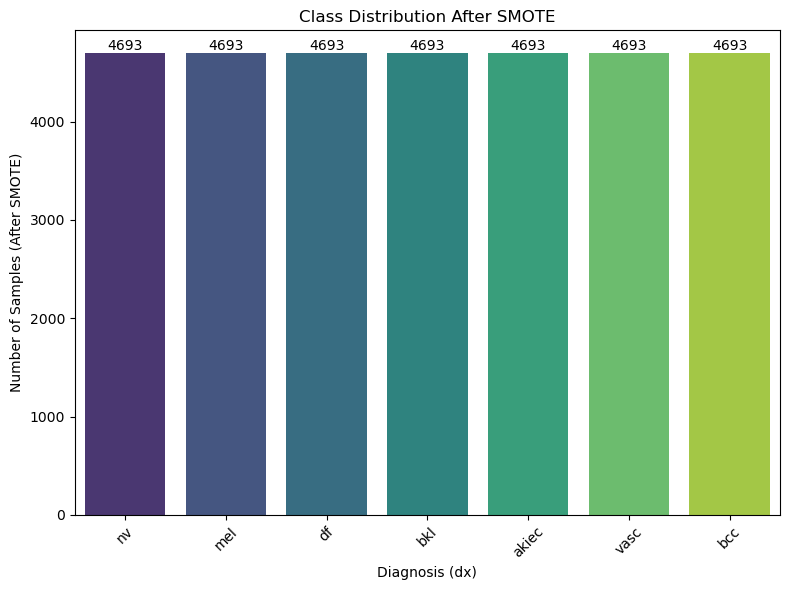

In [16]:
# นับจำนวนแต่ละคลาสหลังทำ SMOTE
counter_after = Counter(y_train_res)
df_after = pd.DataFrame(list(counter_after.items()), columns=["Class", "Count"])

# ถ้ามี LabelEncoder ของ dx อยู่ (เช่น dx_le)
# จะใส่ชื่อโรคจริงแทนตัวเลข class ได้เลย
df_after["dx"] = dx_le.inverse_transform(df_after["Class"])

# -------------------------------
# วาดกราฟแท่ง
# -------------------------------
plt.figure(figsize=(8,6))
ax = sns.barplot(data=df_after, x="dx", y="Count", palette="viridis")

# ใส่จำนวนบนแท่ง
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.xticks(rotation=45)
plt.xlabel("Diagnosis (dx)")
plt.ylabel("Number of Samples (After SMOTE)")
plt.title("Class Distribution After SMOTE")
plt.tight_layout()
plt.show()

# Gradient Boosting

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

In [18]:
# สร้างโมเดล
gb = GradientBoostingClassifier(
    n_estimators=300,   # จำนวนต้นไม้
    learning_rate=0.05, # ความเร็วในการเรียนรู้
    max_depth=3,        # ความลึกของต้นไม้ย่อย
    random_state=42
)

# เทรนโมเดล
gb.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=300,
                           random_state=42)

In [21]:
# ทำนายบน validation set
y_pred = gb.predict(X_val)

In [22]:
# ประเมินผล
acc = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='macro')

print("Gradient Boosting Performance")
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1-score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred))

Gradient Boosting Performance
Accuracy: 0.7656
Macro F1-score: 0.5128

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.31      0.39        49
           1       0.48      0.34      0.40        77
           2       0.52      0.46      0.49       165
           3       0.75      0.18      0.29        17
           4       0.59      0.45      0.51       167
           5       0.84      0.94      0.89      1006
           6       0.71      0.57      0.63        21

    accuracy                           0.77      1502
   macro avg       0.63      0.46      0.51      1502
weighted avg       0.74      0.77      0.75      1502



<Figure size 800x600 with 0 Axes>

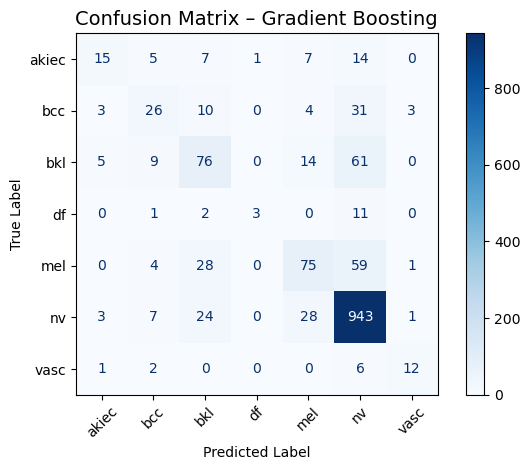

In [37]:
# Confusion matrix
labels = dx_le.classes_  # ดึงชื่อโรคเรียงตามลำดับ encoder

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", xticks_rotation=45, values_format='d')

plt.title("Confusion Matrix – Gradient Boosting", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [25]:
# ทำนายผลบน Test set
y_pred_test = gb.predict(X_test)

# แปลง label กลับเป็นชื่อโรคจริง (dx)
y_pred_labels = dx_le.inverse_transform(y_pred_test)

y_test_series = pd.Series(y_test, index=meta.index[-len(y_test):])  # ใช้ index สุดท้ายของ meta

submission = pd.DataFrame({
    "image_id": meta.loc[y_test_series.index, "image_id"],
    "dx": y_pred_labels
})

submission.to_csv("submission_gradient_boosting.csv", index=False)
print("Complete")

Complete


# Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier
meta_rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=24,
    random_state=42,
    n_jobs=-1
)
meta_rf.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=24, n_estimators=600, n_jobs=-1,
                       random_state=42)

In [27]:
y_val_pred = meta_rf.predict(X_val)

In [28]:
# ประเมินผล
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

print("Random Forest")
print("\nAccuracy : ",f"{accuracy_score(y_val, y_val_pred):.4f}")
print("Macro F1 :", f"{f1_score(y_val, y_val_pred, average='macro'):.4f}")
print("Classification_report")
print(classification_report(y_val,y_val_pred))

Random Forest

Accuracy :  0.7763
Macro F1 : 0.5677
Classification_report
              precision    recall  f1-score   support

           0       0.54      0.41      0.47        49
           1       0.51      0.53      0.52        77
           2       0.55      0.55      0.55       165
           3       0.38      0.18      0.24        17
           4       0.52      0.56      0.54       167
           5       0.89      0.90      0.89      1006
           6       0.76      0.76      0.76        21

    accuracy                           0.78      1502
   macro avg       0.59      0.55      0.57      1502
weighted avg       0.77      0.78      0.77      1502



<Figure size 800x600 with 0 Axes>

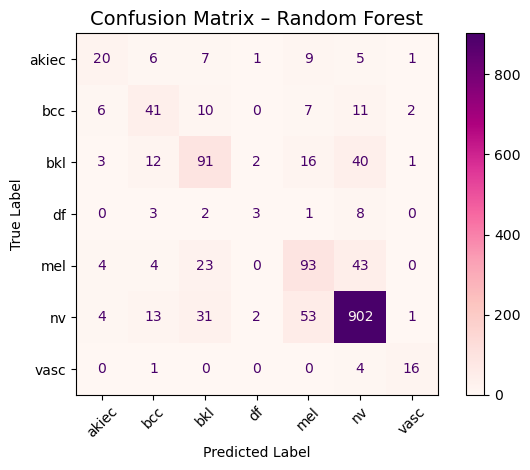

In [36]:
# แสดง Confusion Matrix
labels = dx_le.classes_

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8,6))
rfmodel = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
rfmodel.plot(cmap='RdPu', xticks_rotation=45, values_format='d')

plt.title("Confusion Matrix – Random Forest", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [30]:
# ทำนายผลบน Test set
y_pred_test_rf = meta_rf.predict(X_test)

# แปลง label กลับเป็นชื่อโรคจริง (dx)
y_pred_labels = dx_le.inverse_transform(y_pred_test)

y_test_series = pd.Series(y_test, index=meta.index[-len(y_test):])  # ใช้ index สุดท้ายของ meta

submission = pd.DataFrame({
    "image_id": meta.loc[y_test_series.index, "image_id"],
    "dx": y_pred_labels
})

submission.to_csv("submission_Random_Forest.csv", index=False)
print("Complete")

Complete


# Evaluate & Load the best models

จากที่ได้ทำสองโมเดล Gradient Boosting กับ Random Forest พบว่าทั้งสองให้ค่า Accuracy ที่ใกล้เคียงกัน โดย Gradient Boosting ให้ค่า 77% ในขณะที่ Random Forest ให้ค่า 78% ดังนั้นเมื่อเทียบจากค่า Accuracy จะได้ว่า Random Forest เป็นโมเดลที่ดีกว่าในการแยกคลาสโรคผิวหนัง

In [33]:
#บันทึกโมเดลที่เลือก
import joblib

joblib.dump(meta_rf, "best_model_random_forest.pkl")
print("Complete: best_model_random_forest.pkl")

Complete: best_model_random_forest.pkl
